Entrenando...
VECTORES LATENTES PARA LA CIFRA SELECCIONADA
MEDIA (mu) - dimensión 20:
[ 0.17657544  0.8271857   0.83327264 -0.3326565  -0.65335476 -0.14011475
 -1.3572088   0.90534145  2.5192351  -0.8204354  -0.09302553  1.2369716
  1.074173    0.4930858   0.5509103  -1.1171501  -0.4613103  -1.0100964
  0.05283734  0.57198906]

VARIANZA (sigma^2) - dimensión 20:
[0.01623275 0.01338296 0.05700124 0.3285906  0.12085573 0.16706532
 0.1087062  0.17884113 0.04883726 0.03595088 0.02178498 0.07375002
 0.04841857 0.07823063 0.10862286 0.22310072 0.11665031 0.19674493
 0.06440811 0.10119635]


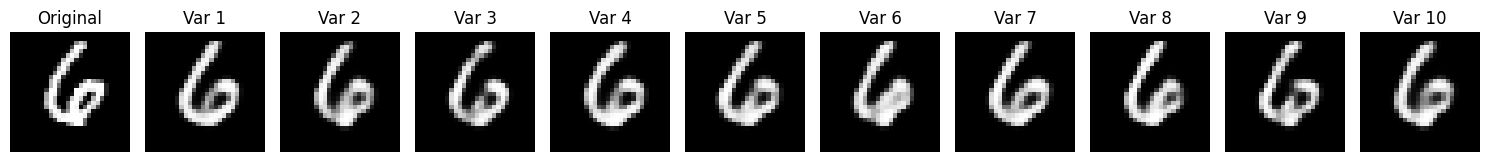

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

# --- CONFIGURACIÓN ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
latent_dim = 20
epochs = 20

# --- MODELO VAE (Arquitectura de Media y Sigma) ---
class VAE(nn.Module):
    def __init__(self):
        super(VAE, self).__init__()
        # Codificador (Encoder)
        self.fc1 = nn.Linear(784, 400)                # Capa de entrada (imagen a capa oculta)
        self.fc_mu = nn.Linear(400, latent_dim)       # Salida para la MEDIA
        self.fc_logvar = nn.Linear(400, latent_dim)   # Salida para el LOG-VARIANZA

        # Decodificador (Decoder)
        self.fc3 = nn.Linear(latent_dim, 400)         # Inicia la reconstrucción
        self.fc4 = nn.Linear(400, 784)                # Salida final (vuelve a 784 píxeles)

    # trasforma la imagen en el vector media y logvar
    def encode(self, x):
        h1 = F.relu(self.fc1(x))
        return self.fc_mu(h1), self.fc_logvar(h1)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)                 # Convertimos log-varianza a desviación estándar
        eps = torch.randn_like(std)                   # Ruido aleatorio (variabile)
        return mu + eps * std

    # reconstrucion de la imagen
    def decode(self, z):
        h3 = F.relu(self.fc3(z))
        return torch.sigmoid(self.fc4(h3))

# --- ENTRENAMIENTO RÁPIDO ---
# Preparacion de los datos
transform = transforms.ToTensor()
train_loader = torch.utils.data.DataLoader(
    datasets.MNIST('./data', train=True, download=True, transform=transform),
    batch_size=128, shuffle=True)

model = VAE().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

print("Entrenando...")
model.train()
for epoch in range(epochs):
    for data, _ in train_loader:
        data = data.to(device)
        optimizer.zero_grad()

        # 1. Pasar la imagen por el encoder
        mu, logvar = model.encode(data.view(-1, 784))

        # 2. Generar un punto aleatorio z
        z = model.reparameterize(mu, logvar)

        #3. Reconstruir la imagen
        recon = model.decode(z)

        # 4. Calcular la perdida total: suma de BCE y KLD
        loss = F.binary_cross_entropy(recon, data.view(-1, 784), reduction='sum') + (-0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()))

        # 5. Backpropagation
        loss.backward()
        optimizer.step()

# --- GENERACIÓN E IMPRESIÓN DE VECTORES ---
model.eval()
with torch.no_grad():
    # Seleccion de una imagen de ejemplo
    data_iter = iter(train_loader)
    images, _ = next(data_iter)
    una_imagen = images[0:1].to(device)

    # Obtenemos Media y Log-Varianza de esta imagen
    mu, logvar = model.encode(una_imagen.view(-1, 784))
    varianza = torch.exp(logvar) # Convertimos log-var a varianza real

    # --- IMPRESIÓN DE VECTORES ---
    print(f"VECTORES LATENTES PARA LA CIFRA SELECCIONADA")
    print(f"MEDIA (mu) - dimensión {latent_dim}:")
    print(mu.cpu().numpy().flatten())
    print(f"\nVARIANZA (sigma^2) - dimensión {latent_dim}:")
    print(varianza.cpu().numpy().flatten())

    # --- VISUALIZACIÓN ---
    # Imagen original
    plt.figure(figsize=(15, 4))
    plt.subplot(1, 11, 1)
    plt.imshow(una_imagen.cpu().squeeze(), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Imagenes sinteticas
    for i in range(10):
        z = model.reparameterize(mu, logvar)           # cada vez genera una copia diferente de la imagen original
        muestra = model.decode(z).cpu().view(28, 28)   # el decoder decodifica y convierte

        plt.subplot(1, 11, i + 2)
        plt.imshow(muestra, cmap='gray')
        plt.title(f"Var {i+1}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()